In [46]:
using Random, MeshGrid, FFTW

include("../../../functions/VizUtils.jl")
using MeshGrid, GLMakie, Random
using .VizUtils

include("SpectralTerms.jl")
using .SpectralTerms

N::Int64 = 32
timesteps::Int = 100
dt = 2^-6

#Random.seed!(1)
fω(x,y) = cos(x) + cos(y)

#Random.seed!(2)
fj(x,y) = 2cos(2x) + cos(y)

forcing(x,y) = 0*x #sin(x) + sin(y)
ν::AbstractFloat = 2^-6
η::AbstractFloat = 2^-6
vis::Bool=true

true

In [ ]:
struct ButcherTableau
    A::Matrix{Float64}
    B::Vector{Float64}
end

function rk_step_explicit(
    f,
    ω::Matrix{ComplexF64}, A::Matrix{ComplexF64},
    dt::Float64, butcher::ButcherTableau
)::Tuple{Matrix{ComplexF64}, Matrix{ComplexF64}}

    s = length(butcher.B)
    k_ω = Vector{Matrix{ComplexF64}}(undef, s)
    k_A = Vector{Matrix{ComplexF64}}(undef, s)

    k_ω[1], k_A[1] = f(ω, A)

    for i in 2:s
        ω_stage = ω .+ dt .* sum(butcher.A[i,j] .* k_ω[j] for j in 1:i-1; init=zeros(ComplexF64, size(ω)))
        A_stage = A .+ dt .* sum(butcher.A[i,j] .* k_A[j] for j in 1:i-1; init=zeros(ComplexF64, size(A)))
        k_ω[i], k_A[i] = f(ω_stage, A_stage)
    end

    ω_new = ω .+ dt .* sum(butcher.B[i] .* k_ω[i] for i in 1:s; init=zeros(ComplexF64, size(ω)))
    A_new = A .+ dt .* sum(butcher.B[i] .* k_A[i] for i in 1:s; init=zeros(ComplexF64, size(A)))

    return ω_new, A_new
end

butcherA::Matrix{Float64} = [
    0 0 0 0;
    2/5 0 0 0;
    (-2889+1428√5)/1024 (3785-1620√5)/1024 0 0;
    (-3365+2094√5)/6040 (-975-3046√5)/2552 (467040+203968√5)/(240845) 0
]
butcherb::Vector{Float64} = [(263+24√5)/1812, (125-1000√5)/3828, (3426304+1661952√5)/(5924787), (30-4√5)/123]
butcher::ButcherTableau = ButcherTableau(butcherA, butcherb)

ButcherTableau([0.0 0.0 0.0 0.0; 0.4 0.0 0.0 0.0; 0.2969776092477536 0.15875964497103556 0.0 0.0; 0.21810038822592054 -3.050965148692931 3.83286476046701 0.0], [0.1747602822626904, -0.551480662878733, 1.2055355993965235, 0.17118478121951902])

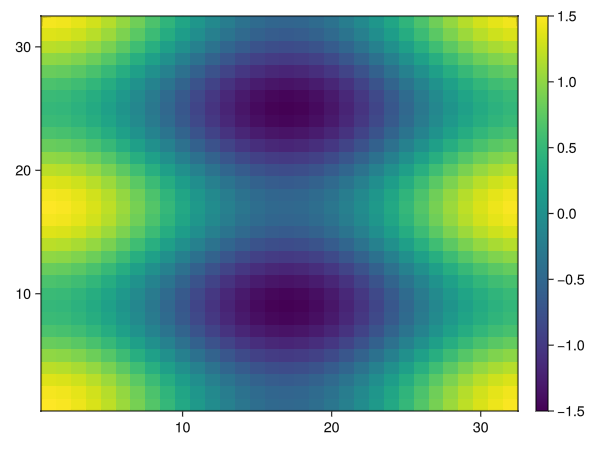

In [48]:
x::Matrix{Float64}, y::Matrix{Float64} = meshgrid(LinRange(0, 2π, N+1)[1:N], LinRange(0, 2π, N+1)[1:N])

u::Array{Float64} = zeros((N,N,timesteps))
v::Array{Float64} = zeros((N,N,timesteps))
Bx::Array{Float64} = zeros((N,N,timesteps))
By::Array{Float64} = zeros((N,N,timesteps))
p::Array{Float64} = zeros((N,N,timesteps))

kvec::Vector{Int} = collect(0:N-1)
kvec[kvec .> N÷2] .-= N

kx::Array{ComplexF64} = reshape(kvec, 1, N)
ky::Array{ComplexF64} = reshape(kvec, N, 1)

mask1d::Vector{ComplexF64} = abs.(kvec) .<= N÷3
mask::Array{ComplexF64} = mask1d' .* mask1d

∇2::Array{ComplexF64} = -kx.^2 .- ky.^2
∇2[1,1] = 1.0

∂x::Matrix{ComplexF64} = im.*kx .* mask
∂y::Matrix{ComplexF64} = im.*ky .* mask
inv_∇2::Matrix{ComplexF64} = complex((1.0 ./ ∇2) .* mask)

∂x[1,1] = 0
∂y[1,1] = 0
inv_∇2[1,1] = 0

kx = kx .* mask
ky = ky .* mask

ω::Array{ComplexF64} = fft(fω.(x,y)) .* mask
A::Array{ComplexF64} = -inv_∇2 .* fft(fj.(x,y)) .* mask
VizUtils.quickmap(real(ifft(A)))

In [49]:
kx

32×32 Matrix{ComplexF64}:
 0.0+0.0im  1.0+0.0im  2.0+0.0im  …  -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im  …  -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im     -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  1.0+0.0im  2.0+0.0im  …  -3.0+0.0im  -2.0+0.0im  -1.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     -0.0+0.0im  -0.0+0.0im  -0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     -0.0+0.0im  -0.0+0.0im  -0.0+0.0im
    ⋮                             ⋱   

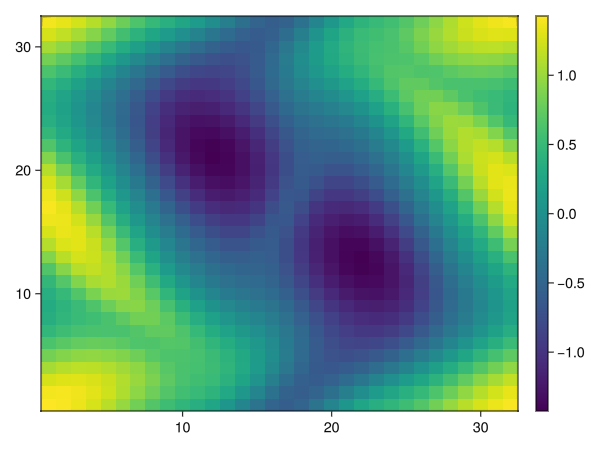

In [50]:
for t ∈ 1:timesteps
    uhat::Matrix{ComplexF64} = -∂y.*inv_∇2.*ω
    vhat::Matrix{ComplexF64} = ∂x.*inv_∇2.*ω
    Bxhat::Matrix{ComplexF64} = ∂y.*A
    Byhat::Matrix{ComplexF64} = -∂x.*A

    u[:,:,t] = real(ifft(uhat))
    v[:,:,t] = real(ifft(vhat))
    Bx[:,:,t] = real(ifft(Bxhat))
    By[:,:,t] = real(ifft(Byhat))

    ux::Matrix{ComplexF64} = real(ifft(∂x .* uhat))
    uy::Matrix{ComplexF64} = real(ifft(∂y .* uhat))
    vx::Matrix{ComplexF64} = real(ifft(∂x .* vhat))
    vy::Matrix{ComplexF64} = real(ifft(∂y .* vhat))

    Bxx::Matrix{ComplexF64} = real(ifft(∂x .* Bxhat))
    Bxy::Matrix{ComplexF64} = real(ifft(∂y .* Bxhat))
    Byx::Matrix{ComplexF64} = real(ifft(∂x .* Byhat))
    Byy::Matrix{ComplexF64} = real(ifft(∂y .* Byhat))

    p_rhs = Bxx.^2 .+ Byy.^2 .+ 2 .*Bxy.*Byx .- ux.^2 .- vy.^2 .- 2 .*uy.*vx
    p[:,:,t] = real(ifft(inv_∇2 .* fft(p_rhs) .* mask))

    rhs = (ω_, A_) -> SpectralTerms.mhd_terms(ω_, A_, ∂x, ∂y, uhat, vhat, ν, η, forcing(x,y), mask)

    ω, A = rk_step_explicit(rhs, ω, A, dt, butcher)
end
VizUtils.quickmap(real(ifft(A)))

In [51]:
if vis
    VizUtils.quickanim(tstp(p), timesteps, 10, "plots/p.gif")
    VizUtils.quickanim(tstp(Bx), timesteps, 10, "plots/Bx.gif")
    VizUtils.quickanim(tstp(By), timesteps, 10, "plots/By.gif")
    VizUtils.quickanim(tstp(u), timesteps, 10, "plots/u.gif")
    VizUtils.quickanim(tstp(v), timesteps, 10, "plots/v.gif")
end

"plots/v.gif"

In [52]:
p

32×32×100 Array{Float64, 3}:
[:, :, 1] =
 -0.2          -0.241682     -0.358194     …  -0.358194     -0.241682
 -0.196157     -0.237038     -0.351312        -0.351312     -0.237038
 -0.184776     -0.223285     -0.330928        -0.330928     -0.223285
 -0.166294     -0.200951     -0.297828        -0.297828     -0.200951
 -0.141421     -0.170895     -0.253281        -0.253281     -0.170895
 -0.111114     -0.134271     -0.199002     …  -0.199002     -0.134271
 -0.0765367    -0.0924876    -0.137075        -0.137075     -0.0924876
 -0.0390181    -0.0471498    -0.0698802       -0.0698802    -0.0471498
 -7.99191e-17  -8.93393e-17  -1.09695e-16     -1.07238e-16  -8.64929e-17
  0.0390181     0.0471498     0.0698802        0.0698802     0.0471498
  0.0765367     0.0924876     0.137075     …   0.137075      0.0924876
  0.111114      0.134271      0.199002         0.199002      0.134271
  0.141421      0.170895      0.253281         0.253281      0.170895
  ⋮                                       